In [157]:
import jax.numpy as jnp
from utils import load_run_data
import matplotlib.pyplot as plt
config, metrics = load_run_data("count_rew_prop/20260107_135302", "DeepSea-bsuite", 'results')
metrics.keys()

dict_keys(['bonus_max', 'bonus_mean', 'bonus_std', 'discount', 'feat_norm', 'i_val_const_obs', 'intrinsic_rew_mean', 'intrinsic_rew_std', 'intrinsic_v_mean', 'intrinsic_v_std', 'lambda_ret_mean', 'lambda_ret_std', 'mean_rew', 'ppo_loss', 'returned_discounted_episode_returns', 'returned_episode', 'returned_episode_lengths', 'returned_episode_returns', 'rnd_loss', 'v_e', 'v_e_pred', 'v_i', 'v_i_pred'])

In [ ]:
N = config['DEEPSEA_SIZE']
reachable_mask = jnp.tril(jnp.ones((N,N)))

### Analysis: 
0. Show the extrinsic value function
1. plot intrinsic and exitrinsic value and predictions thereof
2. plot the absolute value error at the starting state for each.

## Extrinsic Value functions

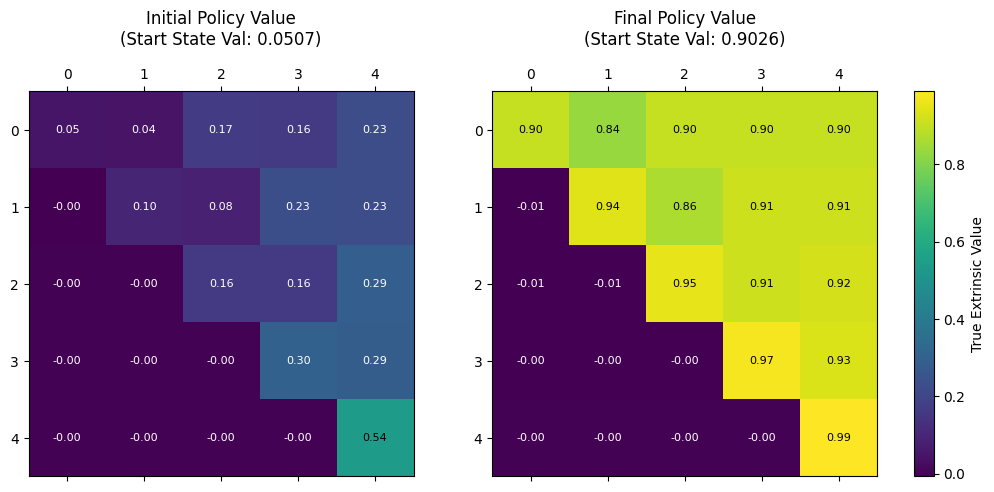

In [182]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract Data
initial_grid = metrics['v_e'][0][0]   # Shape (N, N)
final_grid   = metrics['v_e'][0][5]  # Shape (N, N)

# 2. Determine common color scale (Global Min/Max)
vmin = min(initial_grid.min(), final_grid.min())
vmax = max(initial_grid.max(), final_grid.max())

# 3. Setup Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot Initial ---
im1 = axes[0].matshow(initial_grid, vmin=vmin, vmax=vmax, cmap='viridis')
axes[0].set_title(f"Initial Policy Value\n(Start State Val: {initial_grid[0,0]:.4f})", y=1.1)

# --- Plot Final ---
im2 = axes[1].matshow(final_grid, vmin=vmin, vmax=vmax, cmap='viridis')
axes[1].set_title(f"Final Policy Value\n(Start State Val: {final_grid[0,0]:.4f})", y=1.1)

# --- Shared Colorbar ---
# We anchor the colorbar to both axes so it sits nicely on the right
cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('True Extrinsic Value')

# Optional: Add text annotations if grid is small (N <= 10)
if initial_grid.shape[0] <= 10:
    for (i, j), z in np.ndenumerate(initial_grid):
        axes[0].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)
    for (i, j), z in np.ndenumerate(final_grid):
        axes[1].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)

plt.show()

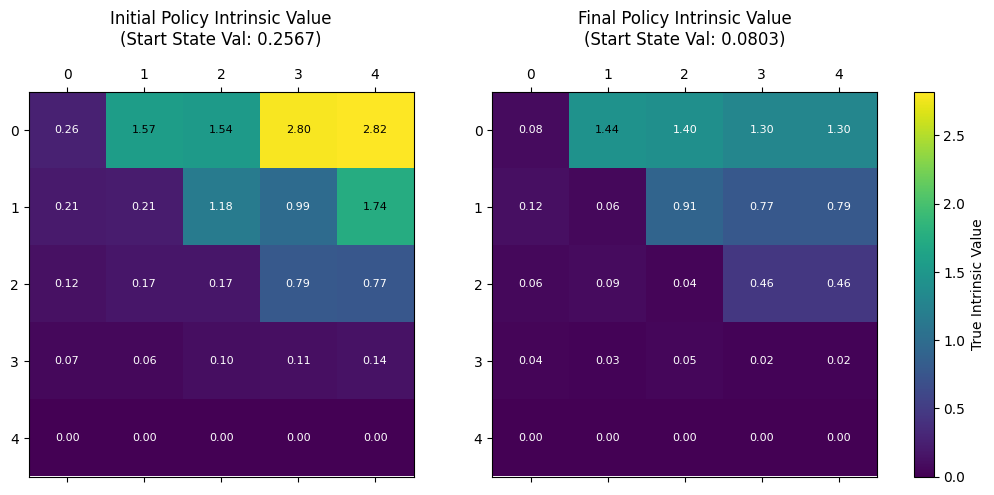

In [181]:
# 1. Extract Data
initial_grid = metrics['v_i'][0][0]   # Shape (N, N)
final_grid   = metrics['v_i'][0][5]  # Shape (N, N)

# 2. Determine common color scale (Global Min/Max)
vmin = min(initial_grid.min(), final_grid.min())
vmax = max(initial_grid.max(), final_grid.max())

# 3. Setup Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot Initial ---
im1 = axes[0].matshow(initial_grid, vmin=vmin, vmax=vmax, cmap='viridis')
axes[0].set_title(f"Initial Policy Intrinsic Value\n(Start State Val: {initial_grid[0,0]:.4f})", y=1.1)

# --- Plot Final ---
im2 = axes[1].matshow(final_grid, vmin=vmin, vmax=vmax, cmap='viridis')
axes[1].set_title(f"Final Policy Intrinsic Value\n(Start State Val: {final_grid[0,0]:.4f})", y=1.1)

# --- Shared Colorbar ---
# We anchor the colorbar to both axes so it sits nicely on the right
cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('True Intrinsic Value')

# Optional: Add text annotations if grid is small (N <= 10)
if initial_grid.shape[0] <= 10:
    for (i, j), z in np.ndenumerate(initial_grid):
        axes[0].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)
    for (i, j), z in np.ndenumerate(final_grid):
        axes[1].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)

plt.show()

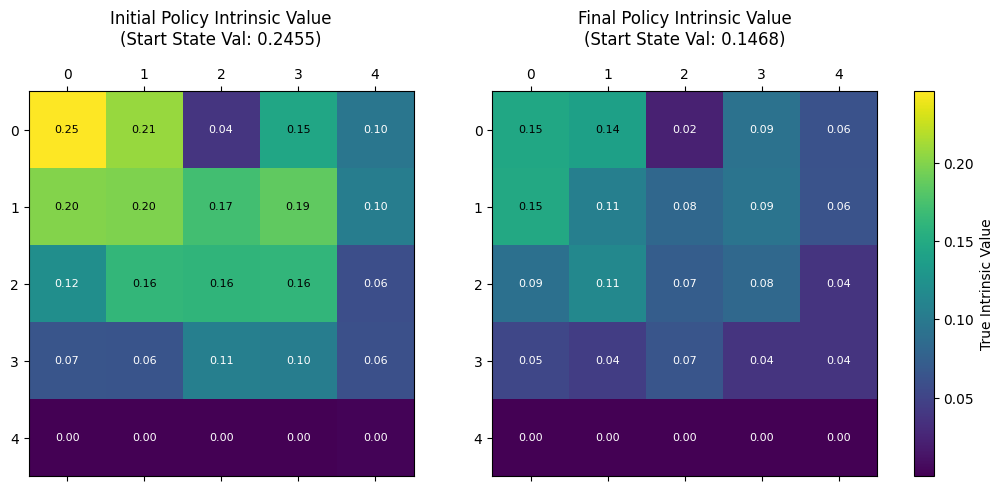

In [180]:
# 1. Extract Data
initial_grid = metrics['v_i_pred'][0][0]   # Shape (N, N)
final_grid   = metrics['v_i_pred'][0][5]  # Shape (N, N)

# 2. Determine common color scale (Global Min/Max)
vmin = min(initial_grid.min(), final_grid.min())
vmax = max(initial_grid.max(), final_grid.max())

# 3. Setup Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot Initial ---
im1 = axes[0].matshow(initial_grid, vmin=vmin, vmax=vmax, cmap='viridis')
axes[0].set_title(f"Initial Policy Intrinsic Value\n(Start State Val: {initial_grid[0,0]:.4f})", y=1.1)

# --- Plot Final ---
im2 = axes[1].matshow(final_grid, vmin=vmin, vmax=vmax, cmap='viridis')
axes[1].set_title(f"Final Policy Intrinsic Value\n(Start State Val: {final_grid[0,0]:.4f})", y=1.1)

# --- Shared Colorbar ---
# We anchor the colorbar to both axes so it sits nicely on the right
cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('True Intrinsic Value')

# Optional: Add text annotations if grid is small (N <= 10)
if initial_grid.shape[0] <= 10:
    for (i, j), z in np.ndenumerate(initial_grid):
        axes[0].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)
    for (i, j), z in np.ndenumerate(final_grid):
        axes[1].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)

plt.show()

In [142]:
metrics['v_i'][0,0,0]

Array([0.25665522, 1.5717849 , 1.53601   , 2.7997077 , 2.8223639 ],      dtype=float32)

In [155]:
t = 4
jnp.sum(reachable_mask * (metrics['v_i_pred'][0][t] - metrics['v_i'][0][t])**2)

Array(0.01009805, dtype=float32)

In [98]:
metrics['v_e_pred'][0][2]

Array([[ 3.8851149e-02,  7.2313666e-02,  2.1327548e-02, -3.6726378e-02,
         1.6927135e-01],
       [-4.7476664e-03,  1.0446399e-01,  1.4867327e-01,  1.6480017e-01,
         5.8556862e-02],
       [-2.3203380e-03,  3.9303061e-03,  2.2020674e-01,  1.1417874e-01,
         1.9362070e-02],
       [ 6.9776494e-03,  2.9815435e-03,  4.7179684e-04,  3.8582194e-01,
         2.0032737e-01],
       [ 2.4012029e-03, -1.1406057e-03,  3.2021813e-03,  6.8559796e-03,
         5.3731608e-01]], dtype=float32)

In [90]:
metrics['v_i'][0][10]

Array([[0.04848   , 1.1031157 , 1.0584165 , 0.95341885, 0.95337987],
       [0.11493032, 0.03725708, 0.69278044, 0.57518274, 0.5755153 ],
       [0.05693827, 0.08398582, 0.02542205, 0.33850336, 0.3384538 ],
       [0.03945373, 0.02960187, 0.04593671, 0.01289955, 0.01297657],
       [0.        , 0.        , 0.        , 0.        , 0.        ]],      dtype=float32)